In [1]:
!pip install matplotlib seaborn
!pip install streamlit seaborn pandas numpy


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st

In [3]:
df = pd.read_csv("../data/ev_market_2026.csv")
df

,brand,model,year,variant,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,...,body_type,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,country_of_origin,market_segment,annual_sales_units,customer_rating,warranty_years
0,Volkswagen,ID. Buzz,2023,Performance,104880.80,118.7,400.0,234.5,3.04,195.0,...,Truck,54.2,2015.0,4,2,Germany,Luxury,202182,4.00,4
1,Toyota,bZ Compact SUV,2022,Premium,48217.41,58.8,219.0,148.1,5.77,159.0,...,SUV,69.0,1709.0,4,0,Japan,Mid-range,7146,3.56,3
2,GM/Chevrolet,Bolt EV,2024,Premium,49651.12,58.2,225.0,104.9,6.84,148.0,...,Van,77.0,1533.0,4,1,US,Mid-range,16590,3.70,3
3,Kia,Sportage EV,2024,Long Range,38131.56,102.5,349.0,66.5,4.66,176.0,...,SUV,65.8,1935.0,4,2,South Korea,Mid-range,127201,3.81,3
4,Tesla,Model 3,2022,Long Range,144079.87,93.9,314.0,298.5,5.64,165.0,...,SUV,38.3,2229.0,4,2,US,Luxury,196401,3.83,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,BMW,i3,2023,Long Range,122665.71,102.1,360.0,92.0,4.21,190.0,...,Hatchback,38.3,1500.0,5,2,Germany,Luxury,66187,3.78,7
1996,Toyota,bZ4X,2024,Performance,66816.55,110.6,367.0,236.3,4.25,181.0,...,Hatchback,23.1,1863.0,4,0,Japan,Premium,11062,3.79,4
1997,Tesla,Model 3,2025,Long Range,49281.26,90.6,325.0,325.6,5.55,167.0,...,Truck,74.6,2920.0,3,3,US,Mid-range,224804,4.10,6
1998,Tesla,Model X,2026,Premium,139665.73,70.7,248.0,330.7,5.07,175.0,...,Coupe,34.8,1500.0,3,2,US,Luxury,165373,3.66,4


In [4]:
import pandas as pd
import numpy as np

In [5]:
!pip install scikit-learn


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
#model_trainning
#select features and target (predict price)

from sklearn.model_selection import train_test_split #untuk membagi data testing dan training
from sklearn.ensemble import RandomForestRegressor #prediksi angka random forest
from sklearn.metrics import r2_score #untuk mengukur seberapa bagus model memprediksi harga

#fitur
X = df[
    [ 'horsepower',
      'torque_nm',
      'charging_speed_kw',
      'warranty_years',
      'customer_rating',
      'year',
      'brand',
      'market_segment'  
    ]
]

#target 
y = df['price_usd']
X = pd.get_dummies(X)

#split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [7]:
#trainning model random forest
price_rf = RandomForestRegressor()
price_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [8]:
#prediksi
y_pred = price_rf.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(r2)

0.9569199642597944


In [9]:
#cek error mae
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred)
print(mae)

4396.071436000002


In [10]:
test_price = pd.DataFrame({
    'horsepower': [500],
    'torque_nm': [700],
    'charging_speed_kw': [350],
    'warranty_years': [8],
    'customer_rating': [4.8],
    'year': [2025],
    'brand': ['Tesla'],
    'market_segment': ['Luxury']
})

# encoding
test_price = pd.get_dummies(test_price)

# samakan kolom
test_price = test_price.reindex(
    columns=X.columns,
    fill_value=0
)

# predict
prediction = price_rf.predict(test_price)
print("Predicted EV Price:", prediction[0])

Predicted EV Price: 118917.72179999996


In [11]:
importance = price_rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)
feature_importance

,Feature,Importance
27,market_segment_Luxury,0.628066
29,market_segment_Premium,0.171533
0,horsepower,0.051812
2,charging_speed_kw,0.023654
16,brand_Mercedes,0.022401
28,market_segment_Mid-range,0.014694
4,customer_rating,0.013154
1,torque_nm,0.013070
21,brand_Tesla,0.011861
3,warranty_years,0.008866


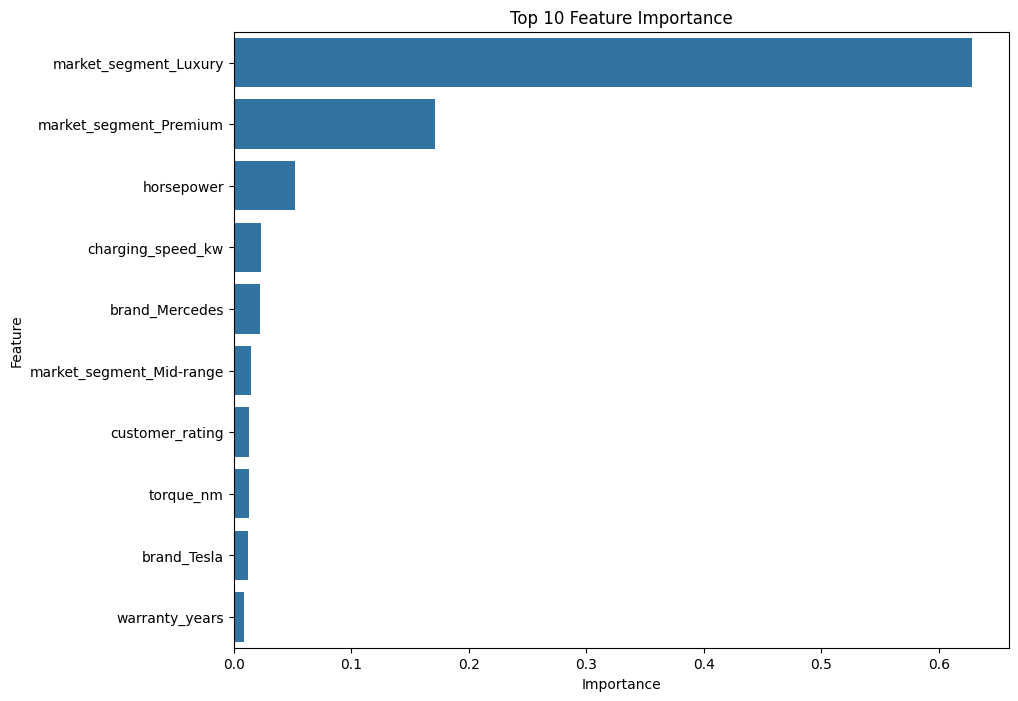

In [12]:
#visual top 10 feature importance
plt.figure(figsize=(10,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance.head(10)
)

plt.title("Top 10 Feature Importance")

plt.show()

In [13]:
import joblib

joblib.dump(price_rf, "../models/price_rf.pkl")

['../models/price_rf.pkl']

In [14]:
joblib.dump(
    feature_importance, "../models/feature_columns.pkl")

['../models/feature_columns.pkl']